# 10 Sampling

We now begin **Part 3 — Statistical Inference**.

> **How can we learn about a large population when we can observe only a sample?**

This chapter connects probability with statistical inference.

## Learning Objectives

- Population vs Sample
- Parameter vs Statistic
- Simple Random Sampling
- Sampling Error
- Repeated Sampling
- Sampling Distribution
- Effect of Sample Size
- Standard Error
- Central Limit Theorem (intuition)
- Sampling Bias

## 1. Population and Sample

A **population** is the entire group of interest. A **sample** is a subset selected from it.

$$
\text{Population}\rightarrow\text{Sample}\rightarrow\text{Statistical Analysis}
$$

Suppose a fictional country has 1,000 households. The 1,000 households are the population. If we survey 50, those 50 form the sample.

## 2. Why Use Samples?

Observing an entire population can be expensive, slow, impossible, or unnecessary. A well-designed sample can provide useful information about the population.

The central question becomes:

> **How representative is the sample?**

## 3. Parameter vs Statistic

A **parameter** describes a population. A **statistic** describes a sample.

$$
\mu=\frac{1}{N}\sum_{i=1}^{N}X_i
\qquad
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

Usually $\mu$ is unknown and is what we want to learn about. $\bar{x}$ can be calculated from the sample.

## 4. Dataset

`10_sampling.csv` is a **synthetic finite population of 1,000 fictional households**.

- `household_id`: fictional identifier
- `region`: fictional region
- `monthly_spending_usd`: synthetic monthly spending

Because this is an educational dataset, we deliberately know the whole population. That lets us compare the true parameter with sample estimates.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd=Path.cwd().resolve()
root=next((p for p in [cwd,*cwd.parents] if (p/"data").is_dir()),None)
if root is None:
    raise FileNotFoundError("Could not find project root containing data/.")
population=pd.read_csv(root/"data"/"10_sampling.csv")
population.head()

,household_id,region,monthly_spending_usd
0,Household_0001,Region_C,235.2
1,Household_0002,Region_B,335.8
2,Household_0003,Region_D,289.9
3,Household_0004,Region_C,260.4
4,Household_0005,Region_A,274.2


In [2]:
print(f"Population size: {len(population)}")
population["monthly_spending_usd"].describe()

Population size: 1000


count    1000.000000
mean      277.443900
std        55.850869
min       115.600000
25%       239.600000
50%       279.400000
75%       314.275000
max       442.500000
Name: monthly_spending_usd, dtype: float64

## 5. The Population Parameter

In [3]:
population_mean=population["monthly_spending_usd"].mean()
population_std=population["monthly_spending_usd"].std(ddof=0)
print(f"Population mean (μ): ${population_mean:.2f}")
print(f"Population SD (σ):   ${population_std:.2f}")

Population mean (μ): $277.44
Population SD (σ):   $55.82


## 6. Simple Random Sampling

In a **Simple Random Sample (SRS)**, population members have equal opportunity to be selected. Here we select 50 households.

In [4]:
sample_50=population.sample(n=50,random_state=42)
sample_mean=sample_50["monthly_spending_usd"].mean()
print(f"Population mean (μ): ${population_mean:.2f}")
print(f"Sample mean (x̄):     ${sample_mean:.2f}")

Population mean (μ): $277.44
Sample mean (x̄):     $274.22


## 7. Sampling Error

$$
\text{Sampling Error}=\bar{x}-\mu
$$

A sample statistic normally differs from the population parameter because only part of the population was observed. This natural variation is not automatically a mistake.

In [5]:
sampling_error=sample_mean-population_mean
print(f"Sampling error: ${sampling_error:.2f}")

Sampling error: $-3.22


## 8. Different Samples Give Different Results

In [6]:
for seed in [1,2,3,4,5]:
    s=population.sample(n=50,random_state=seed)
    print(f"Seed {seed}: sample mean = ${s['monthly_spending_usd'].mean():.2f}")

Seed 1: sample mean = $287.95
Seed 2: sample mean = $282.09
Seed 3: sample mean = $283.26
Seed 4: sample mean = $275.71
Seed 5: sample mean = $275.24


Different random samples produce different values of $\bar{x}$. A statistic therefore has its own random behavior.

## 9. Sampling Distribution

Imagine drawing 1,000 samples of size 50 and calculating $\bar{x}$ each time.

The distribution of these sample means is the **sampling distribution of the sample mean**.

In [7]:
rng=np.random.default_rng(42)
sample_means=np.array([
    rng.choice(population["monthly_spending_usd"],size=50,replace=False).mean()
    for _ in range(1000)
])
print(f"Mean of sample means: ${sample_means.mean():.2f}")
print(f"Population mean:      ${population_mean:.2f}")

Mean of sample means: $276.98
Population mean:      $277.44


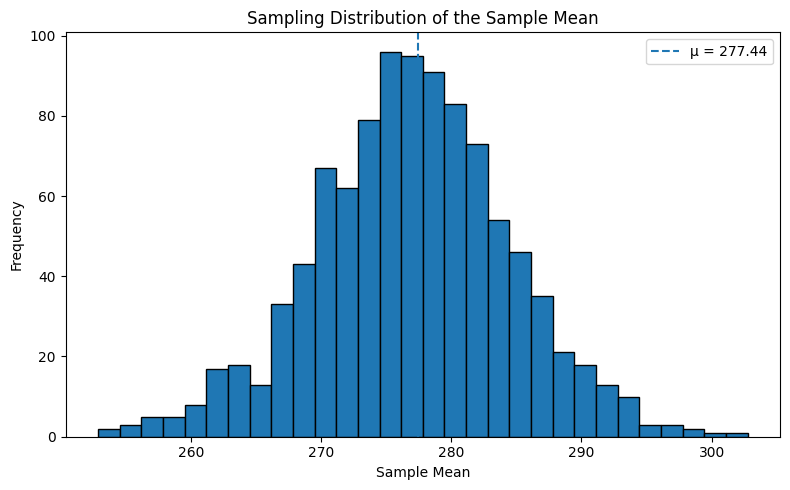

In [8]:
plt.figure(figsize=(8,5))
plt.hist(sample_means,bins=30,edgecolor="black")
plt.axvline(population_mean,linestyle="--",label=f"μ = {population_mean:.2f}")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Sample means tend to cluster around the population mean. In repeated random sampling:

$$
E[\bar{X}]=\mu
$$

## 10. Effect of Sample Size

Compare repeated samples for:

$$n=10,\quad50,\quad200$$

We expect larger samples to produce less variable sample means.

In [9]:
sample_sizes=[10,50,200]
results={}
rng=np.random.default_rng(42)
for n in sample_sizes:
    means=np.array([
        rng.choice(population["monthly_spending_usd"],size=n,replace=False).mean()
        for _ in range(1000)
    ])
    results[n]=means
    print(f"n={n:3d} | mean={means.mean():.2f} | SD={means.std(ddof=1):.2f}")

n= 10 | mean=276.86 | SD=18.21
n= 50 | mean=277.21 | SD=7.77
n=200 | mean=277.24 | SD=3.60


As $n$ increases, the sampling distribution becomes narrower. A larger sample does not guarantee a perfect estimate, but it generally reduces random sampling variability.

## 11. Standard Error

The standard deviation of a sampling distribution is called the **standard error**.

For a sample mean, under the usual large-population approximation:

$$
SE(\bar{X})=\frac{\sigma}{\sqrt{n}}
$$

So larger $n$ means smaller standard error.

In [10]:
for n in sample_sizes:
    approximate_se=population_std/np.sqrt(n)
    simulated_se=results[n].std(ddof=1)
    print(f"n={n:3d} | Approx. SE={approximate_se:.2f} | Simulated SD={simulated_se:.2f}")

n= 10 | Approx. SE=17.65 | Simulated SD=18.21
n= 50 | Approx. SE=7.89 | Simulated SD=7.77
n=200 | Approx. SE=3.95 | Simulated SD=3.60


### Technical Note: Finite Population

We sample without replacement from only 1,000 households. Therefore $\sigma/\sqrt{n}$ is an approximation here.

When a sample is a substantial fraction of a finite population, a **finite population correction** can be applied. We leave that detail for later study.

## 12. Data Distribution vs Sampling Distribution

A **data distribution** describes individual household values.

A **sampling distribution** describes a statistic, such as the sample mean, across many possible samples.

These are fundamentally different objects.

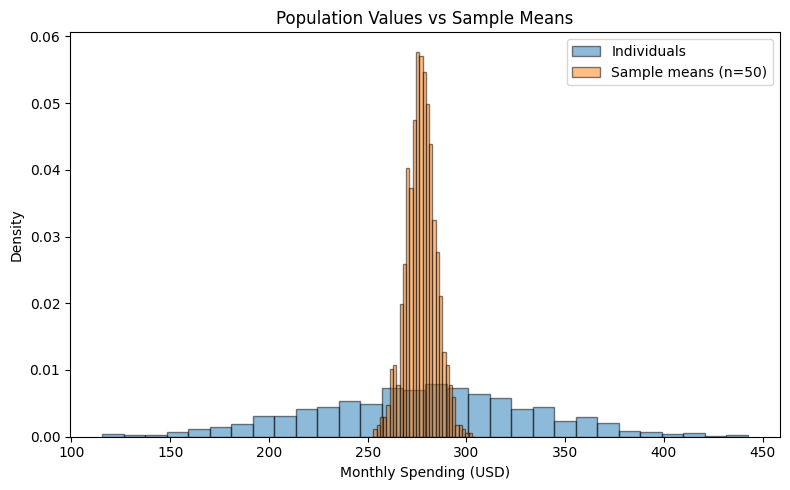

In [11]:
plt.figure(figsize=(8,5))
plt.hist(population["monthly_spending_usd"],bins=30,density=True,alpha=.5,edgecolor="black",label="Individuals")
plt.hist(sample_means,bins=30,density=True,alpha=.5,edgecolor="black",label="Sample means (n=50)")
plt.title("Population Values vs Sample Means")
plt.xlabel("Monthly Spending (USD)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Central Limit Theorem — Intuition

Under suitable conditions, for sufficiently large samples:

$$
\bar{X}\approx N\left(\mu,\frac{\sigma^2}{n}\right)
$$

even if the original population is not perfectly Normal.

For now, remember:

> **Repeated sample means tend to form a stable distribution around the population mean, often becoming approximately Normal as sample size grows.**

## 14. Sample Size Does Not Eliminate Bias

A large sample reduces random sampling variability, but it cannot automatically repair poor sampling design.

Examples include convenience sampling, voluntary response, undercoverage, and systematic nonresponse.

> **Good inference requires both adequate sample size and good sampling design.**

## Exercises

1. Explain population vs sample with your own example.
2. Draw samples of $n=10,30,100$ and compare their means with $\mu$.
3. Repeat sampling with $n=30$ 1,000 times and plot the sample means.
4. Compare sampling variability for $n=10,30,100,300$.
5. Explain why two random samples can have different means.
6. Explain why 100,000 voluntary survey responses can still be biased.
7. Explain the difference between a histogram of observations and a histogram of sample means.

## Summary

The foundation of statistical inference is:

$$
\text{Population}
\rightarrow
\text{Sample}
\rightarrow
\text{Statistic}
\rightarrow
\text{Inference about a Parameter}
$$

You learned about sampling error, sampling distributions, sample size, standard error, CLT intuition, and sampling bias.

Next:

# 11 Confidence Intervals

We will use sampling distributions and standard errors to quantify uncertainty around an estimate.